# Random Agent Baseline Evaluation

This notebook evaluates a random action agent (randomly picks 0 or 1 each step) as a baseline comparison for LGP-evolved agents.

The agent uses the FlappyBird environment directly (bypassing the evaluator framework) to get raw 800x576x3 RGB observations.


In [1]:
# Import required libraries
import numpy as np

# Import FlappyBird environment directly from local module
from flappy_bird_env import FlappyBirdEnv

print("✓ All imports successful!")


✓ All imports successful!


## Environment Setup

Create the FlappyBird environment with `render_mode="rgb_array"` to ensure we get 800x576x3 RGB observations.


In [2]:
# Configuration
MAX_STEPS = 500  # Maximum steps per episode (matching config.yaml)
EPISODES_PER_SEED = 5  # Number of episodes to run per seed
SEEDS = [42, 123, 456, 789, 0]  # Seeds for different runs

# Create environment directly (not via gym.make) to get raw 800x576x3 observations
print("Creating FlappyBird environment...")
test_env = FlappyBirdEnv(render_mode="rgb_array")
obs, info = test_env.reset(seed=42)

print(f"Observation shape: {obs.shape}")
print(f"Observation dtype: {obs.dtype}")
print(f"Observation range: [{obs.min()}, {obs.max()}]")

if obs.shape == (800, 576, 3):
    print("✓ Observation shape is correct: (800, 576, 3)")
else:
    print(f"⚠ Warning: Expected (800, 576, 3), got {obs.shape}")

test_env.close()
print("✓ Environment setup verified!")


Creating FlappyBird environment...
Observation shape: (800, 576, 3)
Observation dtype: uint8
Observation range: [0, 253]
✓ Observation shape is correct: (800, 576, 3)
✓ Environment setup verified!


## Random Agent Implementation

The random agent picks action 0 or 1 randomly at each step.


In [3]:
def evaluate_random_episode(env, seed, episode_idx, max_steps, rng):
    """
    Evaluate a single episode with a random agent.
    
    Args:
        env: FlappyBird environment instance
        seed: Base seed for the run
        episode_idx: Episode index (0-4) to get different but deterministic episodes
        max_steps: Maximum number of steps per episode
        rng: numpy random number generator
        
    Returns:
        Total reward (fitness) for the episode
    """
    # Reset environment with seed + episode_idx for deterministic but varied episodes
    episode_seed = seed + episode_idx
    obs, info = env.reset(seed=episode_seed)
    
    # Verify observation shape
    if obs.shape != (800, 576, 3):
        print(f"⚠ Warning: Expected (800, 576, 3), got {obs.shape} in episode {episode_idx}")
    
    total_reward = 0.0
    
    for step in range(max_steps):
        # Randomly pick action 0 or 1
        action = rng.integers(0, 2)
        
        # Execute action
        obs, reward, terminated, truncated, info = env.step(action)
        
        # Accumulate reward
        total_reward += reward
        
        # Stop if episode ended
        if terminated or truncated:
            break
    
    return float(total_reward)

print("✓ Random agent evaluation function created")


✓ Random agent evaluation function created


## Evaluation Loop

Run the random agent for 5 seeds, with 5 episodes per seed.


In [4]:
# Store results
results = []

print("Starting evaluation...")
print(f"Seeds: {SEEDS}")
print(f"Episodes per seed: {EPISODES_PER_SEED}")
print(f"Max steps per episode: {MAX_STEPS}")
print()

# Evaluate for each seed
for seed in SEEDS:
    print(f"Running seed {seed}...")
    
    # Create RNG with this seed
    rng = np.random.default_rng(seed)
    
    # Create environment instance for this seed (use direct import, not gym.make)
    env = FlappyBirdEnv(render_mode="rgb_array")
    
    # Run episodes
    episode_fitnesses = []
    for episode_idx in range(EPISODES_PER_SEED):
        fitness = evaluate_random_episode(env, seed, episode_idx, MAX_STEPS, rng)
        episode_fitnesses.append(fitness)
        print(f"  Episode {episode_idx + 1}: fitness = {fitness:.4f}")
    
    # Calculate mean fitness for this seed
    mean_fitness = np.mean(episode_fitnesses)
    
    # Store results
    results.append({
        'seed': seed,
        'episode_fitnesses': episode_fitnesses,
        'mean_fitness': mean_fitness
    })
    
    print(f"  Mean fitness for seed {seed}: {mean_fitness:.4f}")
    print()
    
    # Close environment
    env.close()

print("✓ Evaluation complete!")


Starting evaluation...
Seeds: [42, 123, 456, 789, 0]
Episodes per seed: 5
Max steps per episode: 500

Running seed 42...
  Episode 1: fitness = 0.0290
  Episode 2: fitness = 0.0320
  Episode 3: fitness = 0.0240
  Episode 4: fitness = 0.0280
  Episode 5: fitness = 0.0330
  Mean fitness for seed 42: 0.0292

Running seed 123...
  Episode 1: fitness = 0.0270
  Episode 2: fitness = 0.0300
  Episode 3: fitness = 0.0270
  Episode 4: fitness = 0.0270
  Episode 5: fitness = 0.0240
  Mean fitness for seed 123: 0.0270

Running seed 456...
  Episode 1: fitness = 0.0370
  Episode 2: fitness = 0.0300
  Episode 3: fitness = 0.0260
  Episode 4: fitness = 0.0240
  Episode 5: fitness = 0.0280
  Mean fitness for seed 456: 0.0290

Running seed 789...
  Episode 1: fitness = 0.0250
  Episode 2: fitness = 0.0270
  Episode 3: fitness = 0.0300
  Episode 4: fitness = 0.0270
  Episode 5: fitness = 0.0260
  Mean fitness for seed 789: 0.0270

Running seed 0...
  Episode 1: fitness = 0.0300
  Episode 2: fitness = 0

## Results Summary

Display the results in a table format.


In [5]:
# Print summary table
print("=" * 80)
print("RANDOM AGENT BASELINE RESULTS")
print("=" * 80)
print()
print(f"{'Seed':<8} {'Episode 1':<12} {'Episode 2':<12} {'Episode 3':<12} {'Episode 4':<12} {'Episode 5':<12} {'Mean':<12}")
print("-" * 80)

for result in results:
    seed = result['seed']
    episode_fits = result['episode_fitnesses']
    mean_fit = result['mean_fitness']
    
    print(f"{seed:<8} {episode_fits[0]:<12.4f} {episode_fits[1]:<12.4f} {episode_fits[2]:<12.4f} "
          f"{episode_fits[3]:<12.4f} {episode_fits[4]:<12.4f} {mean_fit:<12.4f}")

print("-" * 80)

# Calculate overall statistics
all_fitnesses = [fitness for result in results for fitness in result['episode_fitnesses']]
overall_mean = np.mean(all_fitnesses)
overall_std = np.std(all_fitnesses)
overall_min = np.min(all_fitnesses)
overall_max = np.max(all_fitnesses)

print(f"\nOverall Statistics (across all {len(all_fitnesses)} episodes):")
print(f"  Mean:  {overall_mean:.4f}")
print(f"  Std:   {overall_std:.4f}")
print(f"  Min:   {overall_min:.4f}")
print(f"  Max:   {overall_max:.4f}")
print("=" * 80)


RANDOM AGENT BASELINE RESULTS

Seed     Episode 1    Episode 2    Episode 3    Episode 4    Episode 5    Mean        
--------------------------------------------------------------------------------
42       0.0290       0.0320       0.0240       0.0280       0.0330       0.0292      
123      0.0270       0.0300       0.0270       0.0270       0.0240       0.0270      
456      0.0370       0.0300       0.0260       0.0240       0.0280       0.0290      
789      0.0250       0.0270       0.0300       0.0270       0.0260       0.0270      
0        0.0300       0.0380       0.0320       0.0290       0.0260       0.0310      
--------------------------------------------------------------------------------

Overall Statistics (across all 25 episodes):
  Mean:  0.0286
  Std:   0.0036
  Min:   0.0240
  Max:   0.0380


## Visualization

Create a bar chart showing mean fitness per seed.


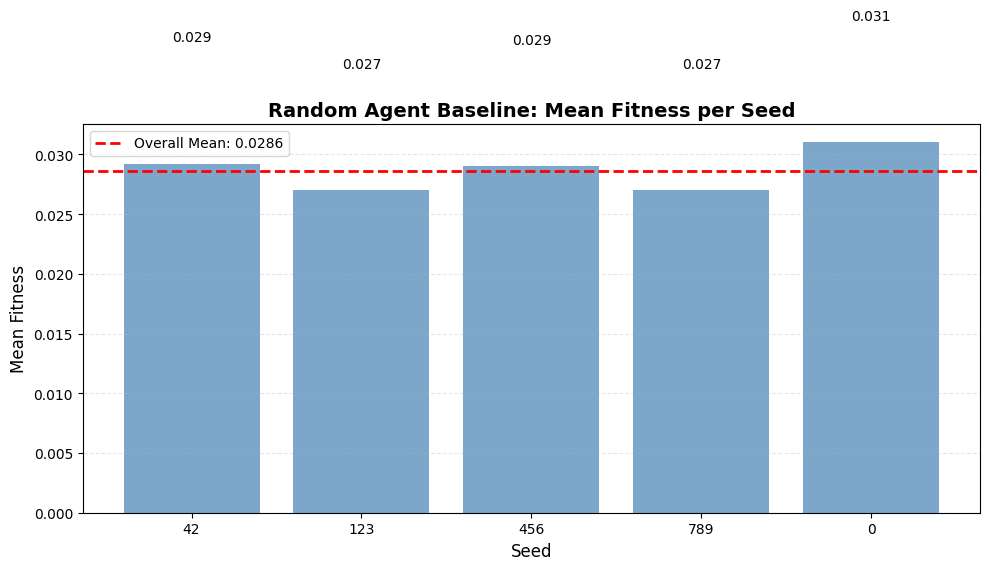

Overall mean fitness: 0.0286


In [6]:
import matplotlib.pyplot as plt

# Extract data for plotting
seeds = [r['seed'] for r in results]
mean_fitnesses = [r['mean_fitness'] for r in results]

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(seeds)), mean_fitnesses, color='steelblue', alpha=0.7)
plt.xlabel('Seed', fontsize=12)
plt.ylabel('Mean Fitness', fontsize=12)
plt.title('Random Agent Baseline: Mean Fitness per Seed', fontsize=14, fontweight='bold')
plt.xticks(range(len(seeds)), seeds)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, mean_fit) in enumerate(zip(bars, mean_fitnesses)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{mean_fit:.3f}', ha='center', va='bottom', fontsize=10)

# Add horizontal line for overall mean
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Mean: {overall_mean:.4f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Overall mean fitness: {overall_mean:.4f}")
